### Task 2:
This task is aiming to provide a binary classification of the column “Type”. 
The dataset is provided into two different tables ("table_1.csv" and "table_2.csv") 
with unique identifier of column “ID”. Tip: This column (ID) can be used to match the 
two tables. 

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import pandas as pd

# Load the data with the correct delimiter
df1 = pd.read_csv('data/table_1.csv', delimiter=';')
df2 = pd.read_csv('data/table_2.csv', delimiter=';')

# Display the first few rows of df1
print(df1.head())

   ID  UKL  GJAH  ZIK   HUI   ERZ    CDx BJZHD  NKJUD        LPI  BJKG
0   0  160  oooo    x  oooo   www    5.0  vvvv   80.0   800000.0  qqqq
1   1  153   rrr  NaN   uuu  pppp    0.0   mmm  200.0  2000000.0  qqqq
2   2    5  oooo    x  oooo   www   19.0    hh   96.0   960000.0    hh
3   3    9  oooo  NaN  oooo   www  120.0   kkk    0.0        0.0   qqq
4   4   40  oooo    y  oooo   www    0.0   mmm  232.0  2320000.0  qqqq


In [28]:
# Merge datasets
merged_df = pd.merge(df1, df2, on="ID")

In [29]:
# Handle missing values
for col in merged_df.columns:
    merged_df[col].fillna(merged_df[col].mode()[0], inplace=True)

# Encode categorical variables
label_encoders = {}
for col in merged_df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    merged_df[col] = le.fit_transform(merged_df[col])
    label_encoders[col] = le

In [31]:
# Separate features and target variable
X = merged_df.drop(columns=["Type", "ID"])
y = merged_df["Type"]

In [32]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [34]:
# Predict
y_pred = model.predict(X_test)

In [35]:
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.99
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        71
           1       0.99      1.00      0.99       824

    accuracy                           0.99       895
   macro avg       0.99      0.94      0.96       895
weighted avg       0.99      0.99      0.99       895



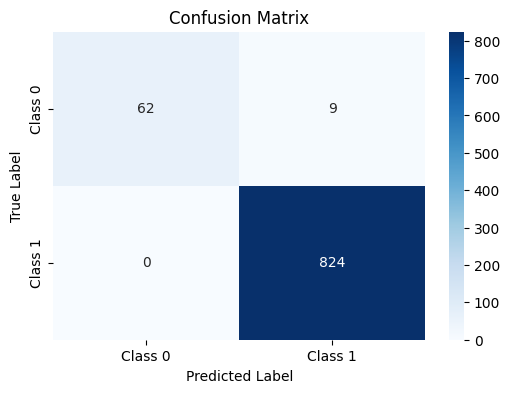

In [36]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [37]:
# Classify a sample
sample_index = 0
sample_input = X_test[sample_index].reshape(1, -1)
predicted_class = model.predict(sample_input)[0]
print(f"Predicted Class for Sample {sample_index}: {predicted_class}")


Predicted Class for Sample 0: 1


In [38]:
# Re-import numpy
import numpy as np

# Select 5 random samples from the test set for classification
sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_inputs = X_test[sample_indices]

# Predict the classes
predicted_classes = model.predict(sample_inputs)

# Print the results
print("Sample Features and Predictions:")
for i, index in enumerate(sample_indices):
    print(f"Sample {i+1}:")
    print(f"Features: {sample_inputs[i]}")
    print(f"Predicted Class: {predicted_classes[i]}")
    print("-")


Sample Features and Predictions:
Sample 1:
Features: [ 1.04776964  2.33108127 -0.40888668 -0.27179568 -2.12795602 -0.25566867
  1.07034928 -0.01329096 -0.01329096  0.62360077  0.57326212 -0.53890315
  1.03294462  0.40590385  0.722571    0.80929329 -0.93008141]
Predicted Class: 1
-
Sample 2:
Features: [-0.29133284 -0.37561014 -0.40888668 -0.27179568  0.41819457 -0.07060547
  0.510759    0.12394866  0.12394866 -1.32006173  0.72167682  2.12756959
 -0.96810611  0.40590385  0.722571    0.80929329  1.28237068]
Predicted Class: 1
-
Sample 3:
Features: [ 0.61925685 -0.37561014 -0.40888668 -0.27179568  0.41819457  0.92587146
  0.23096386 -0.92168656 -0.92168656  0.62360077 -0.61405544  1.77717896
  1.03294462  0.40590385 -1.38394705 -1.23564599  2.22555296]
Predicted Class: 1
-
Sample 4:
Features: [-0.73770034 -0.37561014 -0.40888668 -0.27179568  0.41819457 -0.25578056
  0.23096386 -0.45768593 -0.45768593 -1.32006173 -0.61405544  2.18596803
  1.03294462  0.40590385  0.722571   -1.23564599  0.75